In [43]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (3.5, 2.5)

In [49]:
path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'

survey = 'roman'

# Global parameters

if survey == 'des':
    Nz = 299 #len(z)
    Nt = 4
elif survey == 'roman':   
    sc = 'sc3b_d4'
    Nz = 46 #len(z)
    Nt = 9

Nd = Nz*Nt
r = 500 # hundreds/thousands out of 1M realizations

def get_nzs(survey):
    if survey == 'des':
        ## nz simulations shared by Boyan
        nz = f'{path}/roman_nz_realizations/Fisher_matrix/Tz_realizations_WZ_bq_pile3_0d01.npy'
            
        nz = np.load(nz)             ## shape = (10095, 4, 300) = (Ns, Nt, Nz) = (# of simulations, # of tomo bins, # of redshift)
        nz = nz[:,:,1:]              ## shape = (10095, 4, 299) | (first :) => all 10095 simulations, (second :) => all 4 tomo bins, (third ,1:) => all redshift bins except the first where nz is 0.0.
        Ns = np.shape(nz)[0]          ## Number of simulations: 10095
        Nt = np.shape(nz)[1]          ## Number of tomographic bins: 4
        Nz = np.shape(nz)[2]          ## Number of redshifts: 299
        nz = nz.reshape(Ns, Nt * Nz) ## shape = (10095, 1196) = (Ns, Nt*Nz)
        min_z   = 0.01
        max_z   = 3
        delta_z = (max_z - min_z) / Nz
        zbins   = np.arange(min_z,max_z+delta_z,delta_z)
        zbinsc  = zbins[:-1]+(zbins[1]-zbins[0])/2.
        return nz,zbinsc

    elif survey == 'roman':
        nz = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')
        z = np.array(nz['zbinsc'])
        return nz,z

nz,z = get_nzs(survey)

In [50]:
# A hundred random integers between 1 and 1M
np.random.seed(42)
sims_indexes = np.random.randint(1, 10**6 + 1, size=r)
tot = len(sims_indexes)

if survey == 'roman':
    rows = []
    for j in sims_indexes:
        row = []
        for i in range(Nt):
            normalized = nz[f'bin{i}'][j] / np.trapz(y=nz[f'bin{i}'][j], x=z)
            row.append(normalized)
        rows.append(np.hstack(row))

    nz = np.vstack(rows)
    nbar = np.mean(nz,axis=0)
    ndiff = nz - nbar
    Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff
elif survey == 'des':
    nbar = np.mean(nz,axis=0)
    ndiff = nz - nbar
    Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff

# Unweighted PCA

In [52]:
def pcs(Cn,method='eig'):
    #Cn = np.load(f'{path}/codes/Cn_roman_sc1bd4.npy') #TODO: path changed
    Cn = 0.5*(Cn + Cn.T)
    if method == 'eig':
        eigvals, eigvecs = np.linalg.eig(Cn)
    elif method == 'eigh':
        eigvals, eigvecs = np.linalg.eigh(Cn)
    elif method == 'svd':    
        U, S, VT = np.linalg.svd(Cn)
        eigvecs, eigvals = U,S
    elif method == 'sklearn':
        pca = PCA()
        pca.fit(Cn)
        eigvecs, eigvals = pca.components_, pca.singular_values_
        explained_variance = pca.explained_variance_
        explained_variance_ratio = pca.explained_variance_ratio_
    ######
    if method != 'sklearn':
        eigvecs = np.real(eigvecs)
        eigvals = np.real(eigvals)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]
        eigvecs = eigvecs[:, : Nd]
        eigvals = eigvals[: Nd]
        eigvals = np.maximum(0,eigvals)
        return eigvecs, eigvals
    elif method == 'sklearn':
        return eigvecs, eigvals, explained_variance,explained_variance_ratio 

## The principal components are the same, except for a possible sign flip.  
Here we test 4 different methods to obtain the PCs:   1 - linalg.eig,  2 - linagl.eigh,  3 - linalg.svd,  4 - scikit learn

### Fix one PC and plot its slices across the tomographic bins (example):  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{46}],[\text{PC}^1_{47},\text{PC}^1_{48},\cdots,\text{PC}^1_{92}],6\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{413},\cdots,\text{PC}^1_{414}]\Big]$

<Figure size 350x250 with 0 Axes>

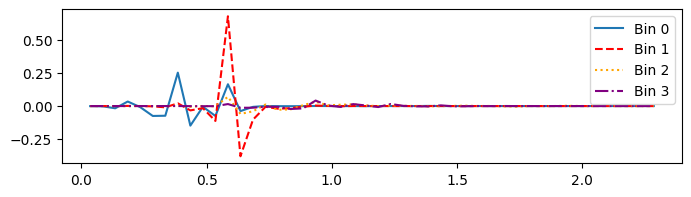

In [58]:
plt.figure()
plt.figure(figsize=(8, 2))
c=["C0","r","orange","purple","k"]
ls = ["-","--",":","-.","-."]

pci=1
k=0
[plt.plot(z[:],eigh_vecs[Nz*(k+0):Nz*(k+1),pci],c=c[k],ls=ls[k],label=f'Bin {k}') for k in range(4)]
plt.legend(loc='upper right')
# plt.title(f'{sc}')


<Figure size 350x250 with 0 Axes>

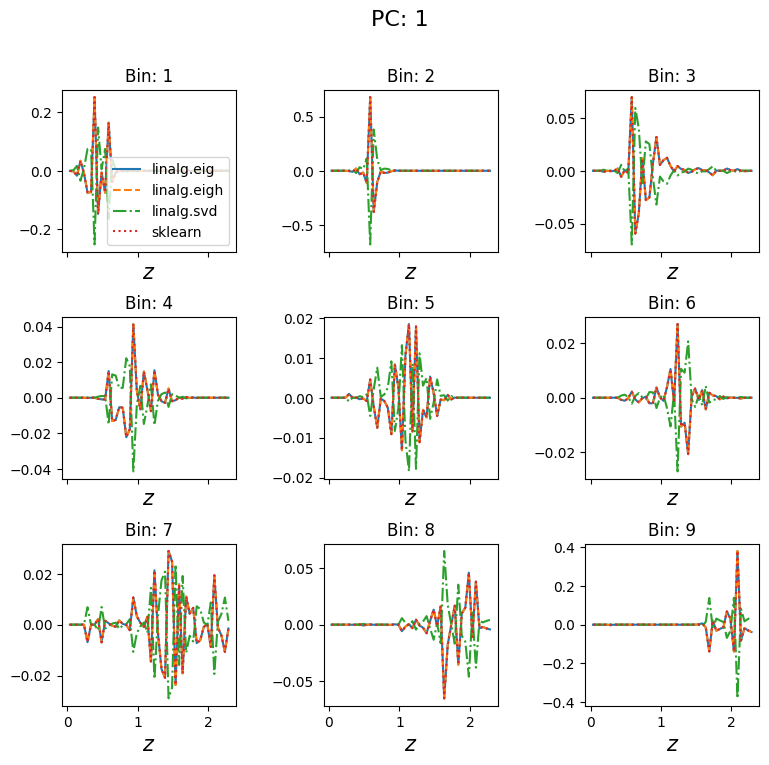

In [59]:
eig_vecs, eig_vals = pcs(Cn,'eig')
eigh_vecs, eigh_vals = pcs(Cn,'eigh')
svd_vecs, svd_vals = pcs(Cn,'svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = pcs(Cn,'sklearn')

plt.figure()
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=False,figsize=(9, 8),
                        gridspec_kw={'wspace':0.5, 'hspace':0.4})
pci = 1

ij = [(i,j) for i in range(nrows) for j in range(ncols)]
for k in range(Nt):
    i,j = ij[k][0],ij[k][1]
    axes[i,j].plot(z,eig_vecs[Nz*k:Nz*(k+1):,pci],ls='-',label='linalg.eig')
    axes[i,j].plot(z,eigh_vecs[Nz*k:Nz*(k+1):,pci],ls='--',label='linalg.eigh')
    axes[i,j].plot(z,svd_vecs[Nz*k:Nz*(k+1):,pci],ls='-.',label='linalg.svd')
    axes[i,j].plot(z,skl_vecs.T[Nz*k:Nz*(k+1):,pci],ls=':',label='sklearn') # here we flip the PC from scikit learn
    axes[i,j].set_title(f'Bin: {k+1}')
    axes[i,j].set_xlabel(r'$z$',fontsize=15)
fig.suptitle(f"PC: {pci}", fontsize=16)
axes[0,0].legend(loc='lower right')

### Pick up the 3 first PCs and plot its slices correspondent to a fixed tomographic bin

/tmp/ipykernel_3255422/282772197.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


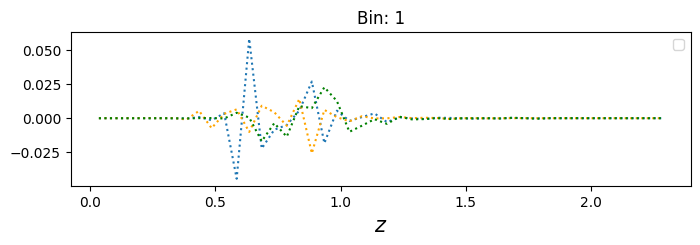

In [129]:
k=0

pci=4
plt.figure(figsize=(8, 2))
cs = ['C0','orange','green']

for pci in range(3):
    # plt.plot(z,svd_vecs[Nz*(k):Nz*(k+1):,pci],label=f'PC {pci}',c=cs[pci])
    # plt.plot(z,svd_vecs[Nz*(k+1):Nz*(k+2):,pci],c=cs[pci])
    # plt.plot(z,svd_vecs[Nz*(k+2):Nz*(k+3):,pci],c=cs[pci],ls='--')
    plt.plot(z,svd_vecs[Nz*(k+3):Nz*(k+4):,pci],c=cs[pci],ls=':')
    # plt.plot(z,svd_vecs[Nz*(k+4):Nz*(k+5):,pci],c=cs[pci],ls='-.')

plt.title(f'Bin: {k+1}')
plt.xlabel(r'$z$',fontsize=15)
plt.legend(loc='best')

## The singular values are the same.  
Here we test 4 different methods to obtain the singular values:   1 - linalg.eig,  2 - linagl.eigh,  3 - linalg.svd,  4 - scikit learn

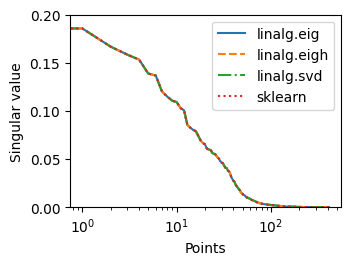

In [11]:
Ms = list(range(Nd))
plt.figure()
plt.plot(Ms,eig_vals,ls='-',label='linalg.eig')
plt.plot(Ms,eigh_vals,ls='--',label='linalg.eigh')
plt.plot(Ms,svd_vals,ls='-.',label='linalg.svd')
plt.plot(Ms,skl_vals,ls=':',label='sklearn')
plt.xscale('log')
plt.ylim(0,0.2)
plt.xlabel('Points')
plt.ylabel('Singular value')
plt.legend(loc='best');

## Lets plot how the PCs's amplitudes are distributed  
The amplitudes $\alpha_i$'s are just the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

nEig:  414
Removed no burn in


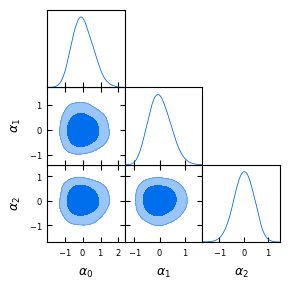

In [12]:
alphas = ndiff @ eigh_vecs
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]
chains = MCSamples(samples=alphas,names=names,labels=labels)

g = plots.get_subplot_plotter(subplot_size=1)
g.triangle_plot(chains,["alpha%s" %i for i in range(3)],filled=True)

## Lets check the function that forward the modified nz to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.

In [13]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

/tmp/ipykernel_1525005/2484394601.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[npc].legend(loc='best')


<Figure size 350x250 with 0 Axes>

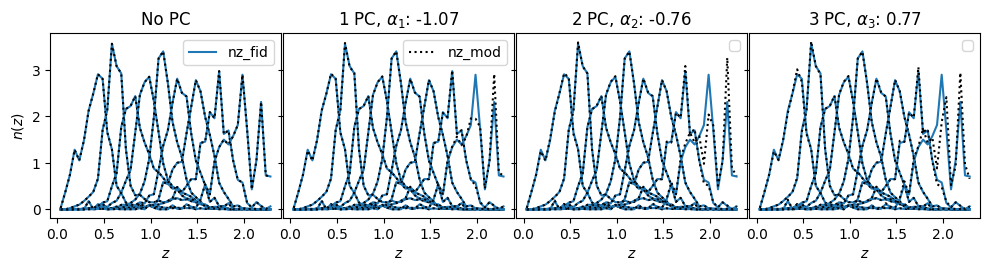

In [14]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eigh_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}^{r_*}(z)=\bar{\mathbf{n}}^r(z) +\sum_{i=1}^Mu^{r_*}_i\mathbf{U}_i(z)$

In [15]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [16]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eigh_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

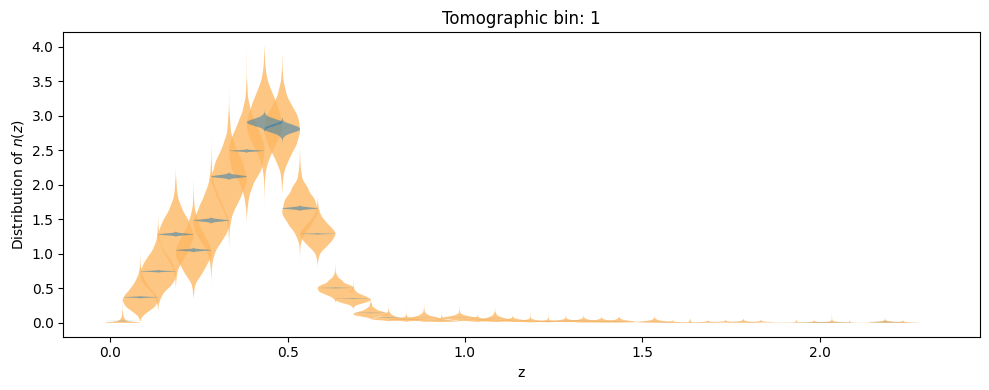

In [17]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n(z)$')
    plt.title('Tomographic bin: 1')
    plt.tight_layout()
    return None
distribution_violinplot()

# Weighted PCA

In [20]:
from numpy import linalg as la
def nearestPD(A):
    """Find the nearest positive-definite matrix to input
    A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
    credits [2].
    [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
    [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
    matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
    """
    B = (A + A.T) / 2
    _, s, V = la.svd(B)
    H = np.dot(V.T, np.dot(np.diag(s), V))
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if isPD(A3):
        return A3
    spacing = np.spacing(la.norm(A))
    I = np.eye(A.shape[0])
    k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3


def isPD(B):
    """Returns true when input is positive-definite, via Cholesky"""
    try:
        _ = la.cholesky(B)
        return True
    except la.LinAlgError:
        return False

In [21]:
def getModes(D, Cn, chisq_threshold=0.1):
    '''Calculate the compression matrix from n to u and the
    modes U that multiply each U.  
    Parameters:
    `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
              matrix of the observables c, and J is the Jacobian dc/dn,
              shape=(N,N)
    `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
    `chisq_threshold`:  Your desired upper bound for the mean error in chisq
              resulting from the compression.
    Returns:
    `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
              covariance matrix of the u's will be the identity.
    `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
    `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
    `resid`:  Mean amount of chisq shift caused by compression.

    You can safely use fewer than `nModes` of the returned X and U if you 
    think the discarded `dchisq` values are small enough.'''

    thr = 1e-25     # Dynamic range threshold for eigenvalues

    # Symmetrize and sqrt D
    D = 0.5*(D + D.T)
    Dval, Dvec = np.linalg.eigh(D)
    # Any negatives are numerical problems
    Dval = np.maximum(0., Dval)

    # And Cn
    Cnval, Cnvec = np.linalg.eigh(Cn)
    Cnval = np.maximum(0., Cnval)

    # Build the keystone matrix and its SVD
    M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
    Um,s,Vmt = np.linalg.svd(M)

    # Sort SV's and throw away unwanted ones
    order = np.argsort(s*s)  # increasing order
    kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                           
    resid = np.sum((s[order[:kill]]**2))

    keep = np.flip(order[kill:])  # Decreasing influence order
    Um = Um[:,keep]
    Vm = Vmt.T[:,keep]
    s = s[keep]

    # Build the encoder
    tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
    X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
    # And the decoder
    tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
    U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s)
    
    return X, U, s*s, resid

In [51]:
# Process all bins, independently
nz_mean_lens = []
nz_lens = []
nzhat_lens = []
u_lens = []
U_lens = []
dchisq_lens = []

path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'
sc = 'sc1b_d6'
ff = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')

def dchisq_func(method='A'):
    for bin in range(6):
        chisq_threshold = 0.00
        nSamp = 5000

        nz = np.array(ff['bin'+str(bin)][::nSamp])
        z = np.array(ff['zbinsc'])
        
        nz = nz / np.trapz(nz,x=z,axis=1)[:,np.newaxis]
        # print('sum_nz:', np.sum(nz[0]))

        nz_mean = np.mean(nz,axis=0)
        nz = nz - nz_mean
        Cn = np.einsum('ij,ik->jk',nz,nz) / (nz.shape[0]-1)
        
        if method == 'A':
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'B':
            D_lens = np.genfromtxt(f'{path}/results/fisher_matrix/roman_sc1bd4/fisher.txt')
            # print(D.shape,Cn.shape)
            D = D_lens[bin*Nz:(bin+1)*Nz, bin*Nz:(bin+1)*Nz].copy()
            X,U,dchisq,resids = getModes(D, Cn, chisq_threshold=chisq_threshold)
        S=dchisq
        # Sort SV's and throw away unwanted ones
        s = S.copy()
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
     
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        dchisq = s[keep]
        dchisq_lens.append(dchisq.copy())
    return dchisq_lens

/tmp/ipykernel_1525005/839546191.py:52: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
/tmp/ipykernel_1525005/839546191.py:49: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
/tmp/ipykernel_1525005/2418044162.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()


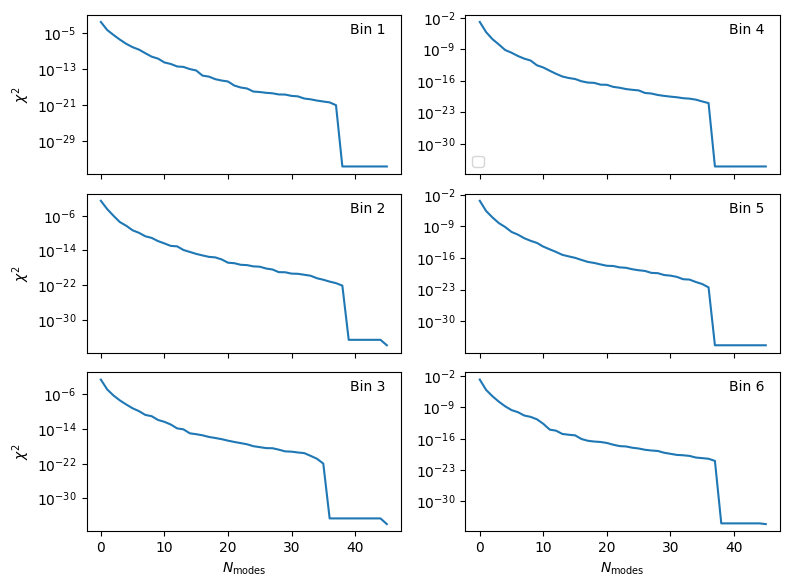

In [52]:
# Plot Chisq shifts
dchisq_lens = dchisq_func(method='B')

fig,ax = plt.subplots(3,2,figsize=(8,6), sharex=True)
for bin in range(6):
    ix = bin//3
    iy = bin%3
    # h1 = ax[iy,ix].plot(dchisq_lens[bin],label='dz=0.01')
    h1 = ax[iy,ix].plot(dchisq_lens[bin])

    ax[iy,ix].text(0.95,0.95,'Bin {:d}'.format(bin+1),transform=ax[iy,ix].transAxes,ha='right',va='top')
    ax[iy,ix].set_yscale('log')
    if iy==2:
        ax[iy,ix].set_xlabel(r'$N_{\rm modes}$')
    if ix==0:
        ax[iy,ix].set_ylabel(r'$ \chi^2$')
ax[0,1].legend()
#fig.suptitle(r'Histograms of $\Delta \chi^2$ for SOMPZ+WZ samples')
plt.tight_layout()